Regression modelling for stock prediction

In [146]:
import yfinance as yf

In [147]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "^GSPC"]
start_date = "2020-01-01"
end_date = "2024-12-31"
df = yf.download(tickers, start=start_date, end=end_date)['Close']

[*********************100%***********************]  6 of 6 completed


In [ ]:
#yesterday's values
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['MSFT(t-1)'] = df['MSFT'].shift(1)
df['GOOGL(t-1)'] = df['GOOGL'].shift(1)
df['AMZN(t-1)'] = df['AMZN'].shift(1)
df['TSLA(t-1)'] = df['TSLA'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)


#"Moving average"
df['AAPL_MA5'] = df['AAPL'].rolling(window=5).mean()
df['MSFT_MA5'] = df['MSFT'].rolling(window=5).mean()
df['GOOGL_MA5'] = df['GOOGL'].rolling(window=5).mean()
df['AMZN_MA5'] = df['AMZN'].rolling(window=5).mean()
df['TSLA_MA5'] = df['TSLA'].rolling(window=5).mean()
df['^GSPC_MA5'] = df['^GSPC'].rolling(window=5).mean()

#set Y Variable  - Next value
df['Target'] = df['AAPL'].shift(-1)
df = df.dropna()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA,^GSPC,AAPL(t-1),MSFT(t-1),GOOGL(t-1),AMZN(t-1),TSLA(t-1),^GSPC(t-1),AAPL_MA5,MSFT_MA5,GOOGL_MA5,AMZN_MA5,TSLA_MA5,^GSPC_MA5,Target
Date,,,,,,,,,,,,,,,,,,,
2020-01-02,72.400497,94.900497,67.873032,152.158371,28.684000,3257.850098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.696640
2020-01-03,71.696640,93.748497,67.517960,150.263748,29.534000,3234.850098,72.400497,152.158371,67.873032,94.900497,28.684000,3257.850098,NaN,NaN,NaN,NaN,NaN,NaN,72.267937
2020-01-06,72.267937,95.143997,69.317589,150.652145,30.102667,3246.280029,71.696640,150.263748,67.517960,93.748497,29.534000,3234.850098,NaN,NaN,NaN,NaN,NaN,NaN,71.928055
2020-01-07,71.928055,95.343002,69.183701,149.278564,31.270666,3237.179932,72.267937,150.652145,69.317589,95.143997,30.102667,3246.280029,NaN,NaN,NaN,NaN,NaN,NaN,73.085098
2020-01-08,73.085098,94.598503,69.676132,151.656357,32.809334,3253.050049,71.928055,149.278564,69.183701,95.343002,31.270666,3237.179932,72.275645,150.801837,68.713683,94.746899,30.480133,3245.842041,74.637497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,253.883102,225.059998,193.734344,431.078857,430.600006,5974.069824,253.107376,432.415894,190.529160,224.919998,421.059998,5930.850098,250.845703,435.927924,190.791937,224.987997,441.564001,5938.954004,256.797241
2024-12-24,256.797241,229.050003,195.207535,435.119690,462.279999,6040.040039,253.883102,431.078857,193.734344,225.059998,430.600006,5974.069824,251.784586,432.930908,190.929306,224.567999,438.048004,5936.840039,257.612701
2024-12-26,257.612701,227.050003,194.699875,433.911407,454.130005,6037.589844,256.797241,435.119690,195.207535,229.050003,462.279999,6040.040039,253.966660,433.073523,192.362680,225.873999,440.848004,5969.925977,254.201370


In [149]:
# Set X and Y variables for linear regression model
import statsmodels.api as sm # type: ignore
import numpy as np

X = df[['AAPL(t-1)', 'MSFT(t-1)', 'GOOGL(t-1)', 'AMZN(t-1)', 'TSLA(t-1)', 
        'AAPL_MA5', 'MSFT_MA5', 'GOOGL_MA5', 'AMZN_MA5', 'TSLA_MA5']]
Y = df['Target']

mask = ~(X.isna().any(axis=1) | Y.isna() | np.isinf(X).any(axis=1) | np.isinf(Y))
X_clean = X[mask]
Y_clean = Y[mask]

X_const = sm.add_constant(X_clean)
model = sm.OLS(Y_clean, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.648e+04
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:15:55   Log-Likelihood:                -3378.4
No. Observations:                1252   AIC:                             6779.
Df Residuals:                    1241   BIC:                             6835.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0925      0.536     -0.172      0.8

In [150]:
# Set X and Y variables for linear regression model
import statsmodels.api as sm # type: ignore
import numpy as np

X = df[['AAPL(t-1)', '^GSPC(t-1)']]
Y = df['Target']

mask = ~(X.isna().any(axis=1) | Y.isna() | np.isinf(X).any(axis=1) | np.isinf(Y))
X_clean = X[mask]
Y_clean = Y[mask]

X_const = sm.add_constant(X_clean)
model = sm.OLS(Y_clean, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 7.848e+04
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:15:55   Log-Likelihood:                -3426.3
No. Observations:                1255   AIC:                             6859.
Df Residuals:                    1252   BIC:                             6874.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7169      0.746     -0.960      0.3

In [151]:
import pandas as pd
df_train_predict = pd.DataFrame()
df_train_predict['Actual'] = df['Target']
df_train_predict['Predicted'] = model.predict(X_const)
df_train_predict

,Actual,Predicted
Date,,
2020-01-02,71.696640,NaN
2020-01-03,72.267937,73.141191
2020-01-06,71.928055,72.430100
2020-01-07,73.085098,73.001477
2020-01-08,74.637497,72.659708
...,...,...
2024-12-23,256.797241,253.119700
2024-12-24,257.612701,253.917694
2024-12-26,254.201370,256.838377


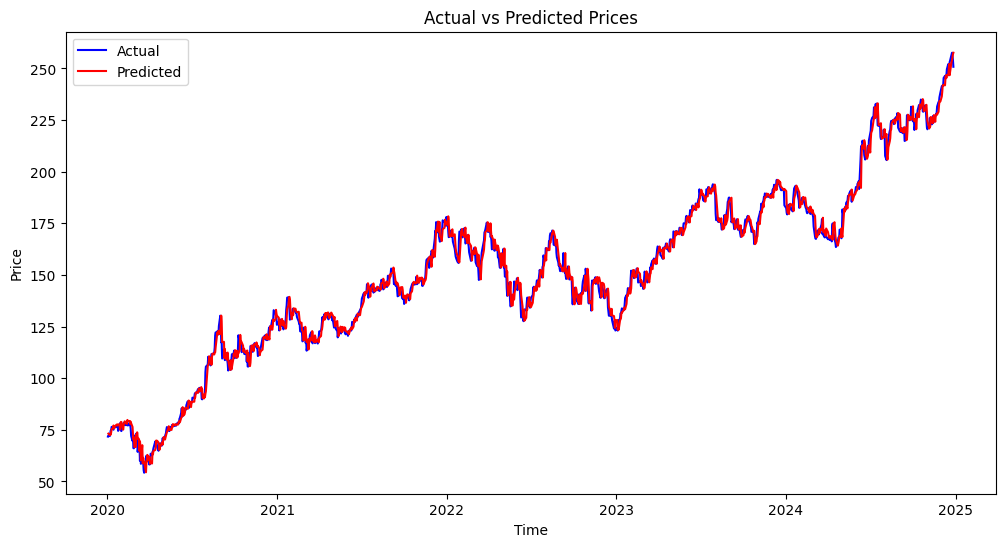

In [152]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_train_predict.index, df_train_predict['Actual'], label='Actual', color='blue')
plt.plot(df_train_predict.index, df_train_predict['Predicted'], label='Predicted', color='red')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

In [153]:
# We need to still test LR assumptions
# We need to check on test data how the model is performing
import seaborn as sns

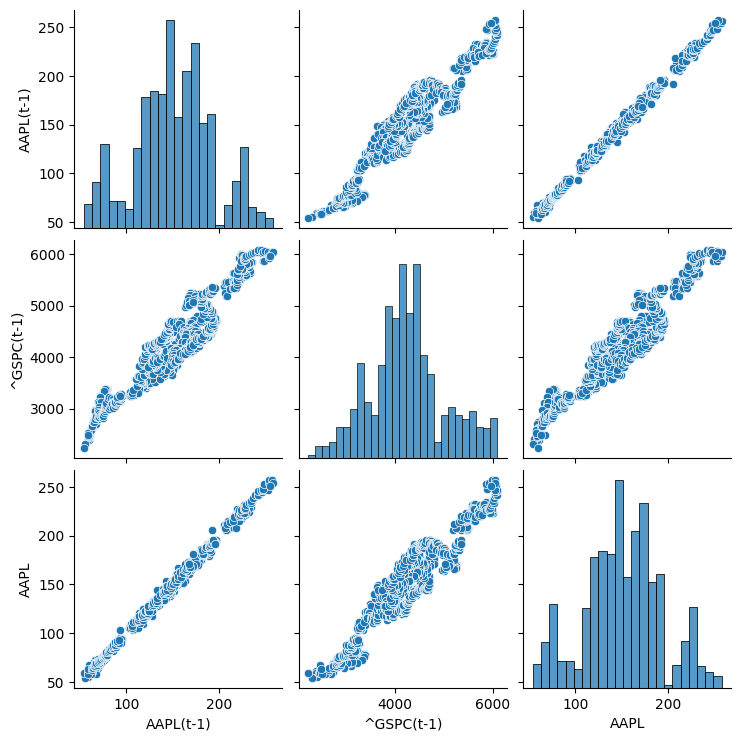

In [154]:
df = df[['AAPL(t-1)', '^GSPC(t-1)', 'AAPL']]
sns.pairplot(df)
#first assumption on linearity on dependent and independent met

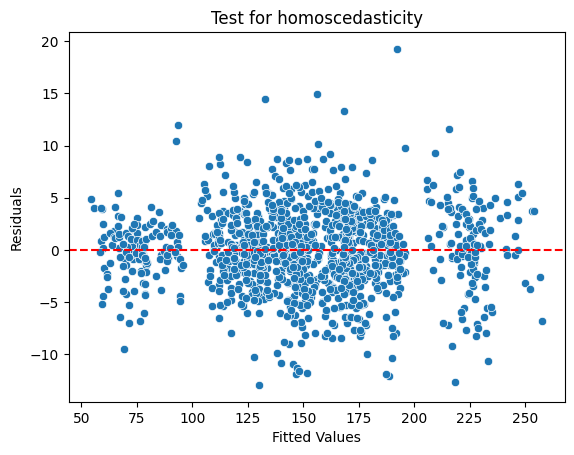

In [155]:
# assumption 2 homoscedasticity met because it's a tube structure
residuals = model.resid
fitted = model.fittedvalues
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Test for homoscedasticity')
plt.show()

In [156]:
#assumption multi linearity = variance inflation factor
# if VIF less than one no multicollinearity, if VIF between 1 and 10 moderate multicollinearity, if VIF greater than 10 high multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif_data = vif_data[1:]
print(vif_data)

      feature       VIF
1   AAPL(t-1)  7.638234
2  ^GSPC(t-1)  7.638234


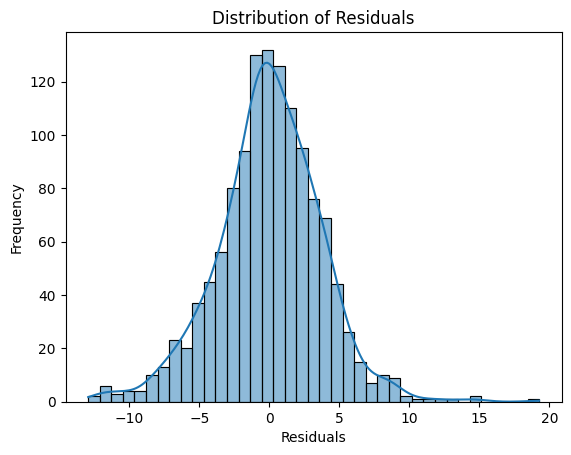

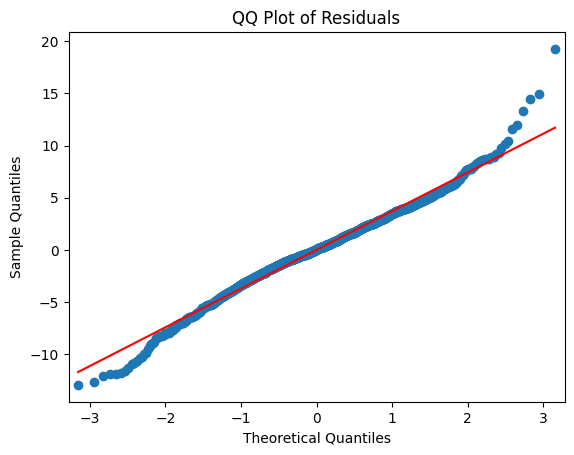

In [157]:
# assumption normality of residuals met
import statsmodels.api as sm
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

qqplot = sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.show()

In [158]:
#Assumption on autocorrelation of residual : Durbin Watson test met
from statsmodels.stats.stattools import durbin_watson
dw_statistic = durbin_watson(residuals)
print(f'Durbin-Watson statistic: {dw_statistic}')
#p-value < 0.05 -> autocorrelation is present, p-value > 0.05 -> no autocorrelation


Durbin-Watson statistic: 1.0412533238489878


In [159]:
#All the 5 conditions of the linear model are met

In [160]:
#Now we will predict the price for 2025
tickers = ["AAPL", "^GSPC"]
start_date = "2025-01-01"
end_date = "2025-03-31"
df = yf.download(tickers, start=start_date, end=end_date)['Close']
df.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,^GSPC
Date,,
2025-01-02,242.525162,5868.549805
2025-01-03,242.037827,5942.470215
2025-01-06,243.668915,5975.379883
2025-01-07,240.894073,5909.029785
2025-01-08,241.381409,5918.250000


In [161]:
#yesterday's values
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)
df = df.dropna()
df.head()

Ticker,AAPL,^GSPC,AAPL(t-1),^GSPC(t-1)
Date,,,,
2025-01-03,242.037827,5942.470215,242.525162,5868.549805
2025-01-06,243.668915,5975.379883,242.037827,5942.470215
2025-01-07,240.894073,5909.029785,243.668915,5975.379883
2025-01-08,241.381409,5918.250000,240.894073,5909.029785
2025-01-10,235.563187,5827.040039,241.381409,5918.250000


In [162]:
X_test = df[['AAPL(t-1)', '^GSPC(t-1)']]
X_test= sm.add_constant(X_test)

df_result = pd.DataFrame()
df_result['Actual'] = df['AAPL']
df_result['Predicted'] = model.predict(X_test)
df_result.head()

,Actual,Predicted
Date,,
2025-01-03,242.037827,242.655518
2025-01-06,243.668915,242.235045
2025-01-07,240.894073,243.866585
2025-01-08,241.381409,241.082685
2025-01-10,235.563187,241.569665


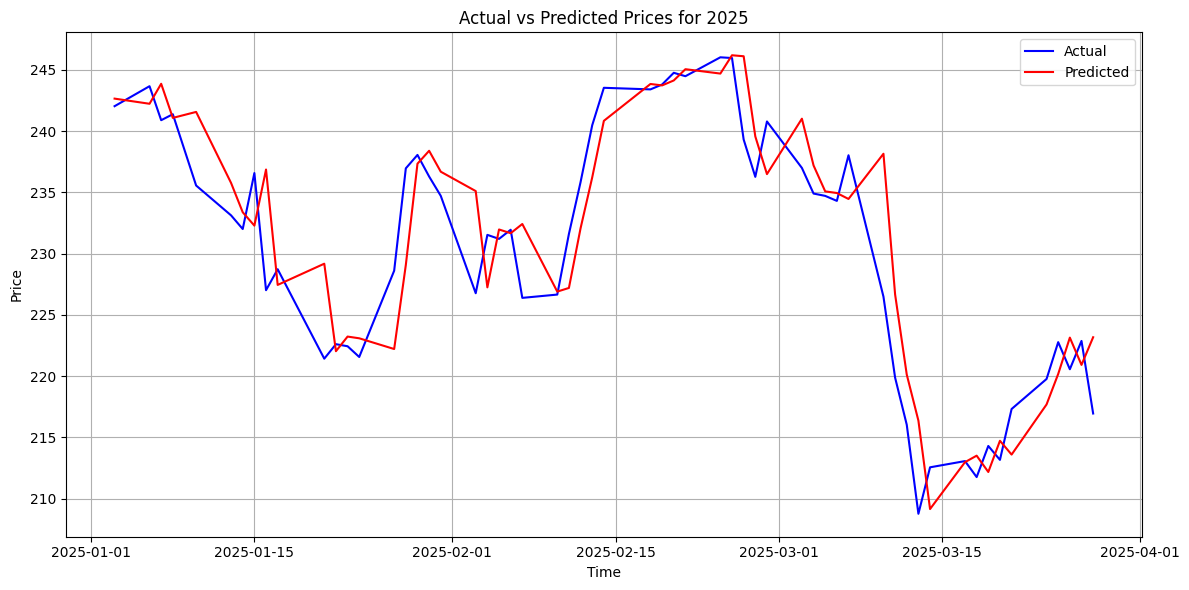

In [163]:
plt.figure(figsize=(12, 6))
plt.plot(df_result.index, df_result['Actual'], label='Actual', color='blue')
plt.plot(df_result.index, df_result['Predicted'], label='Predicted', color='red')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices for 2025')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#It's decent but incorrect, linear regression can only capture linear relationships, stock prices are influenced by many factors and can be highly volatile, making them difficult to predict accurately with a simple linear model.    